# Part 1 Data Analysis & Visualizing

In [4]:
%%bash
apt-get install -y sqlite3 > /dev/null 2>&1
pip install arabic-reshaper python-bidi -q
sqlite3 /content/drive/MyDrive/database.db ".recover" > /content/recovered.sql 2>/dev/null
sqlite3 /content/recovered.db < /content/recovered.sql
echo "Done"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 23.5 MB/s eta 0:00:00
Done


In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib import colors
import seaborn as sns

def ar(text):
    return get_display(arabic_reshaper.reshape(str(text)))


with sqlite3.connect("/content/recovered.db") as conn:
    conn.text_factory = lambda b: b.decode('utf-8', errors='ignore')
    df = pd.read_sql("SELECT * FROM Listings", conn)

print(df.shape)

(810888, 46)


In [6]:
print('data info\n')
print(df.info())
print('data describe\n')
print(df.describe())
print('data head\n')
print(df.head())
print('data tail\n')
print(df.tail())

data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810888 entries, 0 to 810887
Data columns (total 46 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               810888 non-null  int64  
 1   id                    810888 non-null  int64  
 2   uri                   810888 non-null  object 
 3   title                 810715 non-null  object 
 4   price                 810888 non-null  float64
 5   content               809026 non-null  object 
 6   imgs                  810888 non-null  object 
 7   refresh               810888 non-null  int64  
 8   category              810888 non-null  int64  
 9   beds                  514847 non-null  float64
 10  livings               483251 non-null  float64
 11  wc                    482001 non-null  float64
 12  area                  810306 non-null  float64
 13  type                  264715 non-null  float64
 14  street_width          721638 non-null  fl

In [7]:
columns_to_drop=['user_id','user.name','user.phone','user.review','user.rega_id','advertiser_type','path','imgs'
,'native.logo', 'native.title', 'native.image','native.description', 'native.external_url','type']
df.drop(columns=columns_to_drop,inplace=True,errors = "ignore")

col_bool=['ketchen','ac','furnished','daily_rentable','has_extended_details','user.iam_verified']
for col in col_bool:
  df[col]=df[col].map( {0.0: False, 1.0:True,np.nan:False})

df = df[df['price'] > 0]
df = df[(df['area'].isna()) | (df['area'] > 0)]

for col in ['refresh', 'last_update', 'create_time']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')

print(df.shape)
print(df.isnull().sum())

(810867, 32)
id                           0
uri                          0
title                      173
price                        0
content                   1862
refresh                      0
category                     0
beds                    296039
livings                 327635
wc                      328885
area                       582
street_width             89250
age                     280065
last_update                  0
street_direction        145897
ketchen                      0
ac                           0
furnished                    0
location.lat                 0
location.lng                 0
user.img                285912
user.iam_verified            0
rent_period             694481
city                         0
city_id                      0
district                     0
district_id                  0
width                   204309
length                  204506
create_time                  0
has_extended_details         0
daily_rentable            

In [8]:
cat_map = {
    1: 'شقة - إيجار', 2: 'أرض - بيع', 3: 'فيلا - بيع',
    4: 'دور - إيجار', 5: 'فيلا - إيجار', 6: 'شقة - بيع',
    7: 'عمارة - بيع', 8: 'محل - إيجار', 9: 'بيت - بيع',
    10: 'استراحة - بيع', 11: 'بيت - إيجار', 12: 'مزرعة - بيع',
    13: 'استراحة - إيجار', 14: 'مكتب - إيجار', 15: 'أرض - إيجار',
    16: 'عمارة - إيجار', 17: 'مستودع - إيجار', 18: 'مخيم - إيجار',
    19: 'غرفة - إيجار', 20: 'محل - بيع', 21: 'شقة مفروشة',
    22: 'دور - بيع', 23: 'شاليه - إيجار'
}

df['category_name']=df['category'].map(cat_map)
df['property_type'] = df['category_name'].str.split('-').str[0]
df['Contract type'] = df['category_name'].str.split('-').str[1]
df['Contract type'] = df['Contract type'].str.strip()

df['price_million'] = df['price'] / 1_000_000

df['year'] = df['create_time'].dt.year

region_map = {
    # منطقة الرياض
    'الرياض': 'الرياض', 'الخرج': 'الرياض', 'الدرعية': 'الرياض',
    'المزاحمية': 'الرياض', 'ثادق': 'الرياض', 'حوطة بني تميم': 'الرياض',
    'المجمعة': 'الرياض', 'الزلفي': 'الرياض', 'الدوادمي': 'الرياض',
    'شقراء': 'الرياض', 'عفيف': 'الرياض', 'القويعية': 'الرياض',
    'الدلم': 'الرياض', 'الحريق': 'الرياض', 'الغاط': 'الرياض',
    'السليل': 'الرياض', 'رماح': 'الرياض', 'الهياثم': 'الرياض',

    # منطقة مكة المكرمة
    'جدة': 'مكة المكرمة', 'مكة المكرمة': 'مكة المكرمة',
    'الطائف': 'مكة المكرمة', 'الجموم': 'مكة المكرمة',
    'رابغ': 'مكة المكرمة', 'القنفذة': 'مكة المكرمة',
    'الليث': 'مكة المكرمة', 'الخرمة': 'مكة المكرمة',
    'ثول': 'مكة المكرمة', 'بدر': 'مكة المكرمة',
    'مدينة الملك عبدالله الاقتصادية': 'مكة المكرمة','تربه':'مكة المكرمة',

    # منطقة المدينة المنورة
    'المدينة المنورة': 'المدينة المنورة', 'ينبع': 'المدينة المنورة',
    'العلا': 'المدينة المنورة', 'الحناكية': 'المدينة المنورة',
    'خيبر': 'المدينة المنورة', 'مهد الذهب': 'المدينة المنورة',
    'بدر': 'المدينة المنورة', 'املج': 'المدينة المنورة',

    # منطقة الشرقية
    'الدمام': 'الشرقية', 'الخبر': 'الشرقية', 'الظهران': 'الشرقية',
    'الجبيل': 'الشرقية', 'القطيف': 'الشرقية', 'الهفوف': 'الشرقية',
    'المبرز': 'الشرقية', 'حفر الباطن': 'الشرقية', 'بقيق': 'الشرقية',
    'راس تنورة': 'الشرقية', 'النعيرية': 'الشرقية', 'سيهات': 'الشرقية',
    'صفوى': 'الشرقية', 'الخفجي': 'الشرقية', 'تاروت': 'الشرقية',
    'عنك': 'الشرقية',

    # منطقة القصيم
    'بريدة': 'القصيم', 'عنيزة': 'القصيم', 'الرس': 'القصيم',
    'البدائع': 'القصيم', 'البكيرية': 'القصيم', 'الشماسية': 'القصيم',
    'رياض الخبراء': 'القصيم', 'المذنب': 'القصيم','العيون':'القصيم',
    'الكامل':'القصيم',

    # منطقة عسير
    'ابها': 'عسير', 'خميس مشيط': 'عسير', 'محايل': 'عسير',
    'المجاردة': 'عسير', 'بللسمر': 'عسير', 'احد رفيده': 'عسير',
    'تثليث': 'عسير', 'بيشة': 'عسير', 'النبهانية': 'عسير',

    # منطقة جازان
    'جازان': 'جازان', 'صبيا': 'جازان', 'ابو عريش': 'جازان',
    'بيش': 'جازان', 'صامطة': 'جازان', 'احد المسارحة': 'جازان',

    # منطقة حائل
    'حائل': 'حائل', 'بقعاء': 'حائل', 'الغزالة': 'حائل', 'الشنان': 'حائل',

    # منطقة تبوك
    'تبوك': 'تبوك', 'ضبا': 'تبوك', 'تيماء': 'تبوك',
    'الوجه': 'تبوك', 'املج': 'تبوك',

    # منطقة الباحة
    'الباحة': 'الباحة', 'رنية': 'الباحة',

    # منطقة نجران
    'نجران': 'نجران', 'شرورة': 'نجران', 'الوديعة': 'نجران',

    # منطقة الجوف
    'سكاكا': 'الجوف', 'دومة الجندل': 'الجوف', 'القريات': 'الجوف',

    # منطقة الحدود الشمالية
    'عرعر': 'الحدود الشمالية', 'رفحاء': 'الحدود الشمالية', 'طريف': 'الحدود الشمالية',
}

df['region'] = df['city'].map(region_map)
print(df['region'].value_counts())
print(df['category_name'])

region
الرياض             450611
مكة المكرمة        163379
الشرقية            103793
القصيم              24900
عسير                23150
المدينة المنورة     22251
جازان                9430
حائل                 7093
تبوك                 2674
الباحة               1420
نجران                 813
الحدود الشمالية       734
الجوف                 619
Name: count, dtype: int64
0           أرض - بيع
1           أرض - بيع
2           أرض - بيع
3         أرض - إيجار
4           أرض - بيع
             ...     
810883      أرض - بيع
810884    شقة - إيجار
810885      أرض - بيع
810886      شقة - بيع
810887    دور - إيجار
Name: category_name, Length: 810867, dtype: object


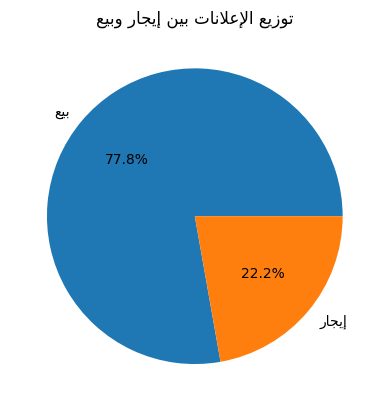

In [9]:
labels_ar = [ar(l) for l in df['Contract type'].value_counts().index]
plt.pie(df['Contract type'].value_counts(),
        labels=labels_ar, autopct='%1.1f%%')
plt.title(ar('توزيع الإعلانات بين إيجار وبيع'))
plt.show()

- من الاعلانات للبيع 77.8% مقابل 22.3% للايجار
- السوق العقاري السعودي موجّه بشكل كبير نحو البيع
- هذا يعكس ثقافة التملك في السعودية

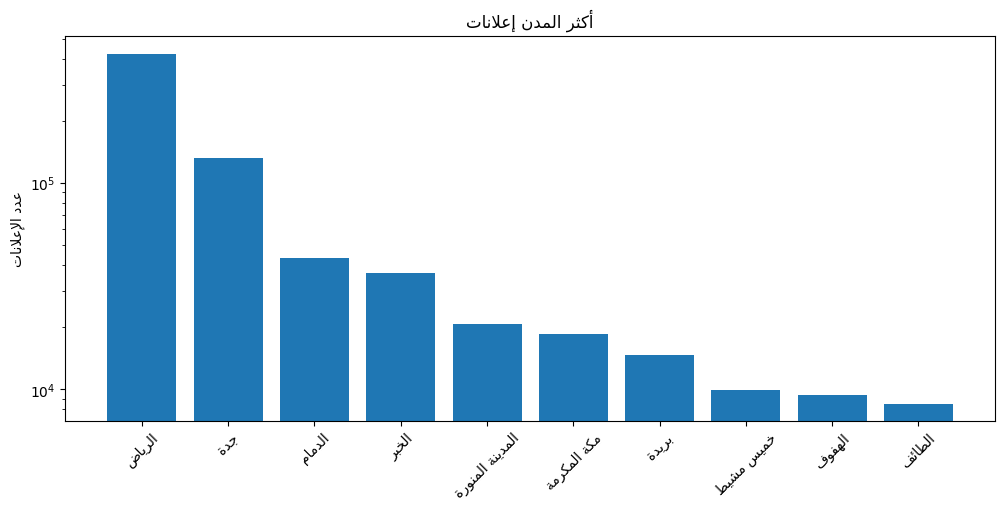

In [10]:
top_cities = df['city'].value_counts().head(10)
labels = [ar(city) for city in top_cities.index]

plt.figure(figsize=(12, 5))
plt.yscale('log')
plt.bar(labels, top_cities.values)
plt.ylabel(ar('عدد الإعلانات'))
plt.title(ar('أكثر المدن إعلانات'))
plt.xticks(rotation=45)
plt.show()

- الرياض تهيمن بفارق ضخمة
- الرياض وجدة والدمام والخبر تمثل أكثر من 80% من الإعلانات
- المدن الصغيرة نشاطها محدود جداً مقارنة بالكبرى

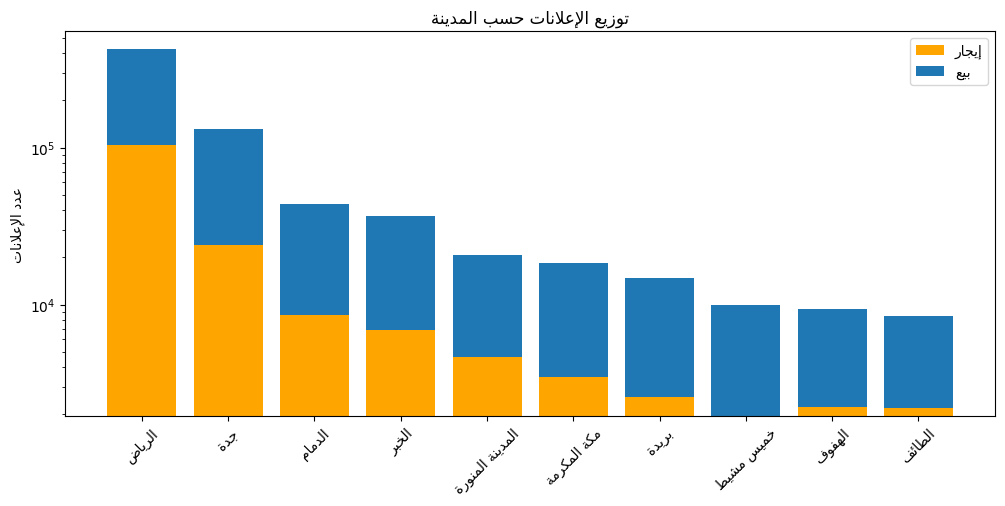

In [11]:
top_cities = df['city'].value_counts().head(10).index

rent = df[df['Contract type'] == 'إيجار']['city'].value_counts().reindex(top_cities, fill_value=0)
sale = df[df['Contract type'] == 'بيع']['city'].value_counts().reindex(top_cities, fill_value=0)

labels = [ar(city) for city in top_cities]

plt.figure(figsize=(12, 5))
plt.bar(labels, rent.values, label=ar('إيجار'),color='orange' )
plt.bar(labels, sale.values, bottom=rent.values,  label=ar('بيع'))
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel(ar('عدد الإعلانات'))
plt.title(ar('توزيع الإعلانات حسب المدينة'))
plt.legend()
plt.show()

- الرياض الأعلى في الإيجار — يعكس كثرة الوافدين فيها
- بريدة والهفوف والطائف يغلب عليها البيع
- جدة متوازنة نسبياً بين الإيجار والبيع
- اما خميس مشيط يسيطر عليها العقود البيع

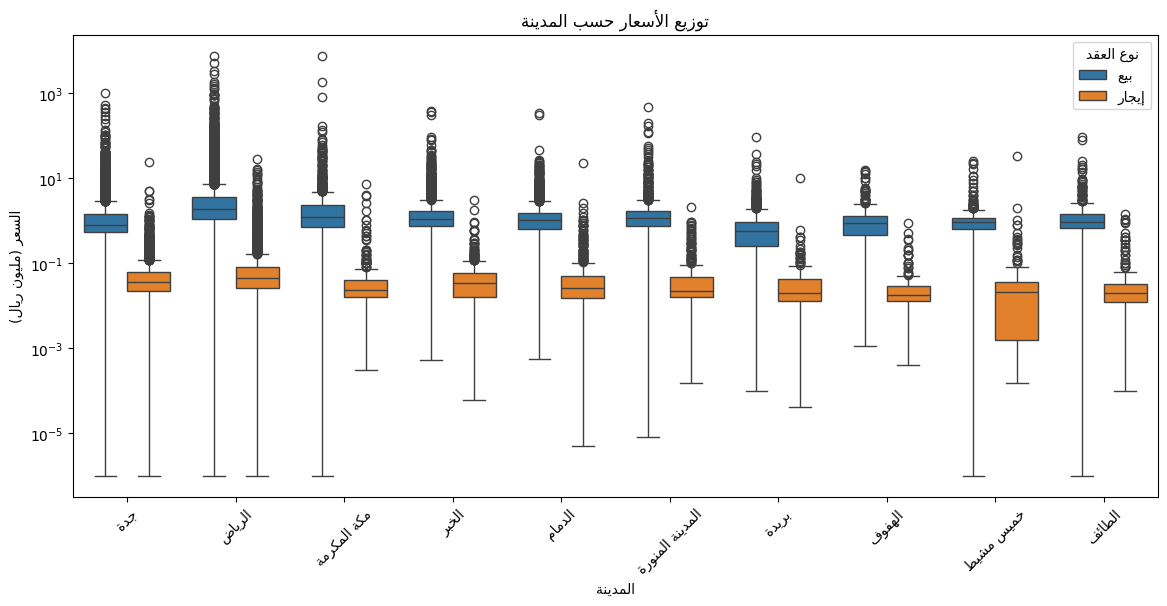

In [12]:
city_ar_map = {city: ar(city) for city in df['city'].unique()}

df_top = df[df['city'].isin(top_cities)].sample(50000, random_state=42).copy()
df_top['city_label'] = df_top['city'].map(city_ar_map)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top, x='city_label', y='price_million', hue='Contract type')
plt.yscale('log')
plt.ylabel(ar('السعر (مليون ريال)'))
plt.xlabel(ar('المدينة'))
plt.title(ar('توزيع الأسعار حسب المدينة'))
handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs], title=ar('نوع العقد'))
plt.xticks(rotation=45)
plt.show()

- أسعار البيع متقاربة بين المدن الكبرى
- الرياض وجدة فيها أعلى outliers — عقارات فاخرة جداً
- الإيجار متقارب في كل المدن
- خميس مشيط إيجارها أعلى من المتوقع مقارنة بحجمها
- في هذي الرسمة طلع لخميس مشيط ان لها عقود من نوع الايجار عكس رسمة السابقة

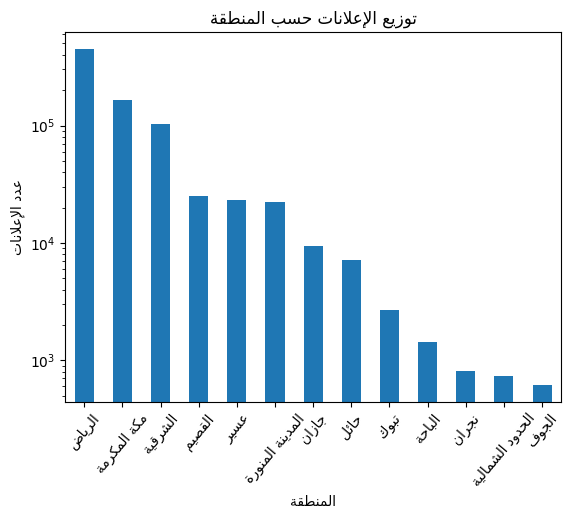

In [23]:
labels = [ar(r) for r in df['region'].value_counts().index]
df['region'].value_counts().plot(kind='bar')
plt.xticks(range(len(labels)), labels, rotation=50)
plt.yscale('log')
plt.xlabel(ar('المنطقة'))
plt.ylabel(ar('عدد الإعلانات'))
plt.title(ar('توزيع الإعلانات حسب المنطقة'))
plt.show()

- المناطق الحدودية (الجوف، الحدود الشمالية، نجران) نشاطها ضعيف جداً

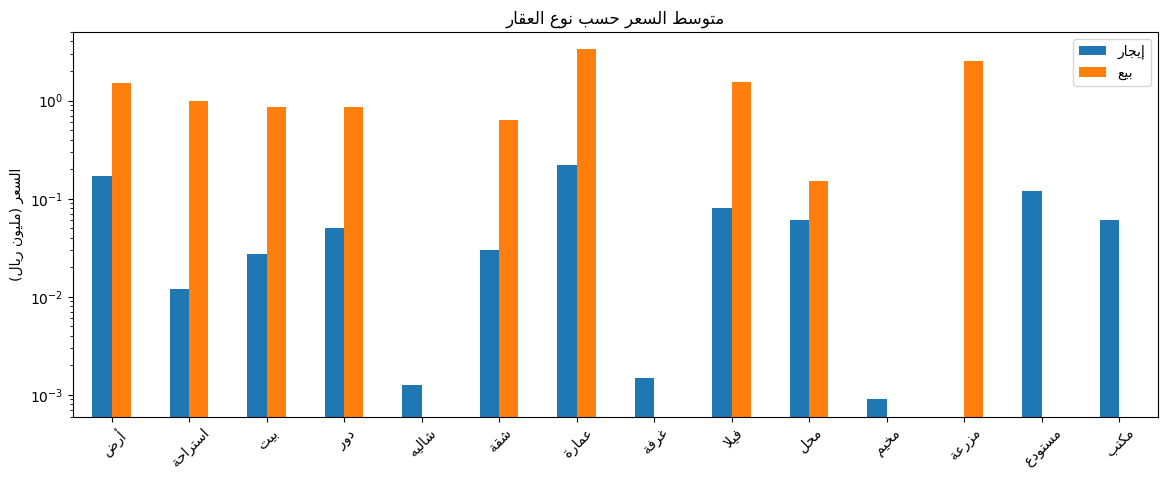

In [25]:
rent = df[df['Contract type'] == 'إيجار'].groupby('property_type')['price_million'].median()
sale = df[df['Contract type'] == 'بيع'].groupby('property_type')['price_million'].median()

data = pd.DataFrame({'إيجار': rent, 'بيع': sale})
data.index = [ar(i) for i in data.index]
data.plot(kind='bar', figsize=(14, 5))
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel(ar('السعر (مليون ريال)'))
plt.title(ar('متوسط السعر حسب نوع العقار'))
handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs])

plt.show()

- العمارة والمزرعة الأغلى في البيع (أكثر من مليون ريال)
- الغرفة والمخيم الأرخص في الإيجار (أقل من 1000 ريال)
- البيع دائماً أعلى بكثير من الإيجار في كل الأنواع
- الشاليه والمخيم والغرفة ما عندها عقود بيع — يُأجرن فقط

/tmp/ipykernel_4649/1114079395.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ar(l.get_text()) for l in ax.get_xticklabels()], rotation=45)


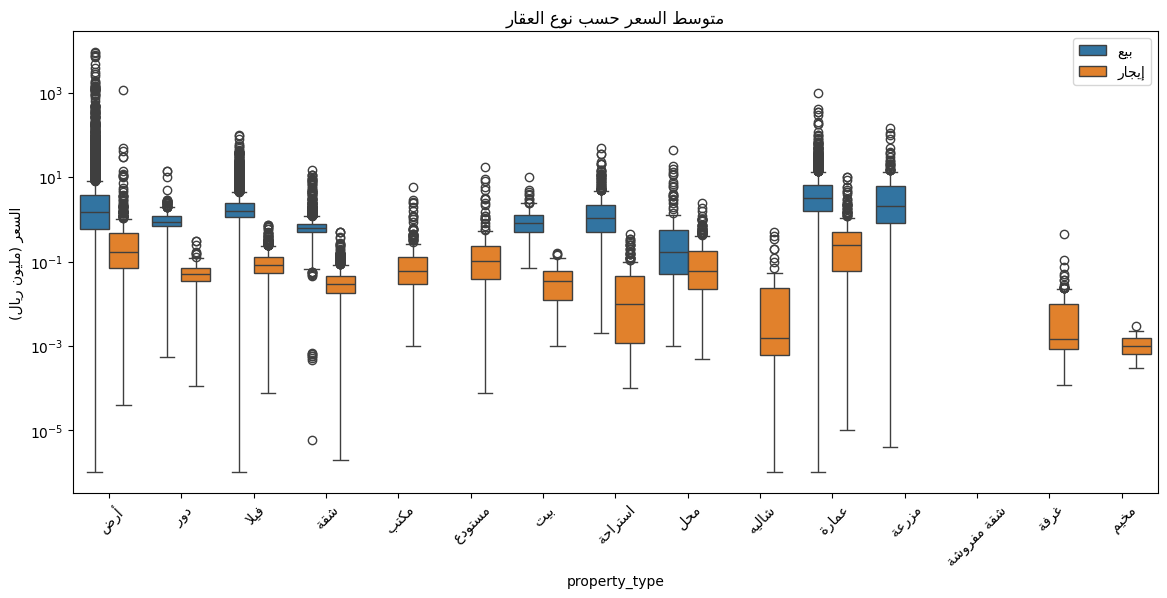

In [26]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['property_type'].notna()].sample(50000, random_state=42),
            x='property_type', y='price_million', hue='Contract type')
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel(ar('السعر (مليون ريال)'))
plt.title(ar('متوسط السعر حسب نوع العقار'))
handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs])
ax = plt.gca()
ax.set_xticklabels([ar(l.get_text()) for l in ax.get_xticklabels()], rotation=45)
plt.show()

- الأرض الأعلى تباين في الأسعار — من آلاف لمليارات
- العمارة والمزرعة عندها (outliers) ضخمة جداً
- الغرفة والمخيم والشقة المفروشة أسعار إيجارها منخفضة جداً
- المحل عنده تداخل بين الإيجار والبيع

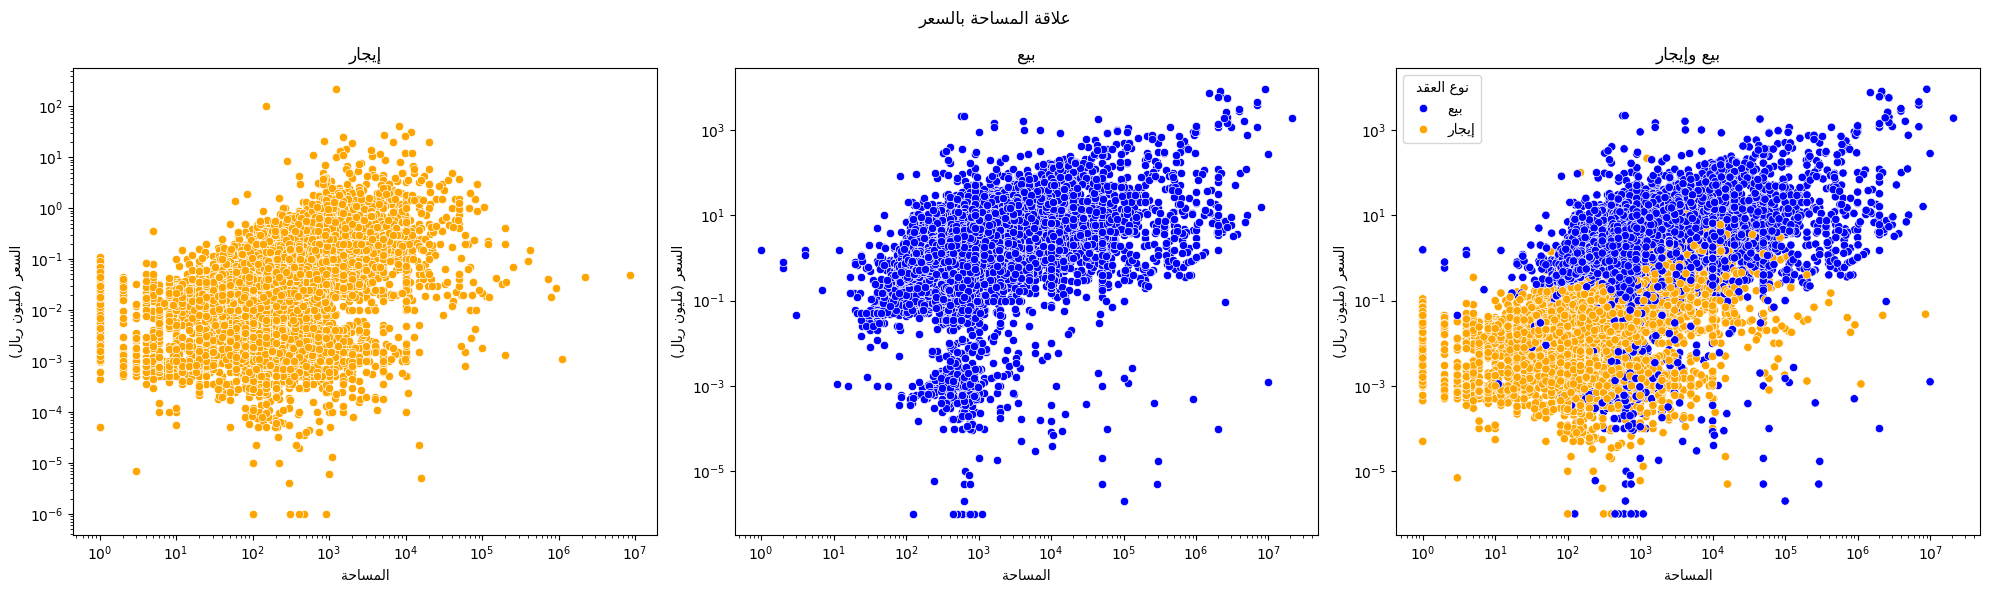

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sample = df.sample(100000, random_state=42)
rent_sample = sample[sample['Contract type'] == 'إيجار']
sale_sample = sample[sample['Contract type'] == 'بيع']

sns.scatterplot(data=rent_sample, x='area', y='price_million', ax=axes[0], color='orange')
axes[0].set_title(ar('إيجار'))
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel(ar('المساحة'))
axes[0].set_ylabel(ar('السعر (مليون ريال)'))

sns.scatterplot(data=sale_sample, x='area', y='price_million', ax=axes[1], color='blue')
axes[1].set_title(ar('بيع'))
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(ar('المساحة'))
axes[1].set_ylabel(ar('السعر (مليون ريال)'))

sns.scatterplot(data=sample, x='area', y='price_million', hue='Contract type',
                palette={'بيع': 'blue', 'إيجار': 'orange'}, ax=axes[2])
axes[2].set_title(ar('بيع وإيجار'))
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel(ar('المساحة'))
axes[2].set_ylabel(ar('السعر (مليون ريال)'))

handles, labs = axes[2].get_legend_handles_labels()
axes[2].legend(handles, [ar(l) for l in labs], title=ar('نوع العقد'))
fig.suptitle(ar('علاقة المساحة بالسعر'))





plt.tight_layout()
plt.show()

- علاقة طردية واضحة — كلما كبرت المساحة ارتفع السعر
- البيع يبدأ من مساحات صغيرة ويصل لأسعار خيالية
- الإيجار أسعاره أكثر ثباتاً بغض النظر عن المساحة
- البيع يظهر تباين أكبر عند المساحات الكبيرة

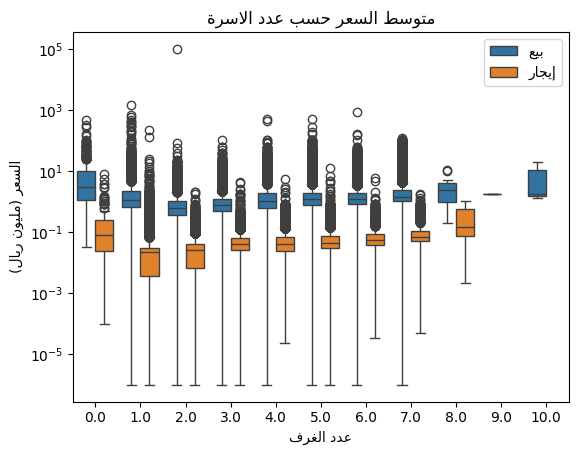

In [28]:
sns.boxplot(data=df[df['beds'] <= 10], x='beds', y='price_million', hue='Contract type')
plt.yscale('log')
plt.ylabel(ar('السعر (مليون ريال)'))
plt.title(ar('متوسط السعر حسب عدد الاسرة'))
plt.xlabel(ar('عدد الغرف'))

handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs])
plt.show()

- 0 غرف سعرها مرتفع — يعني أراضي وعقارات تجارية
- البيع أعلى من الإيجار في كل الأعداد
- زيادة الغرف لا تعني دائماً سعراً أعلى
-  8-10 غرف بيانات قليلة جداً

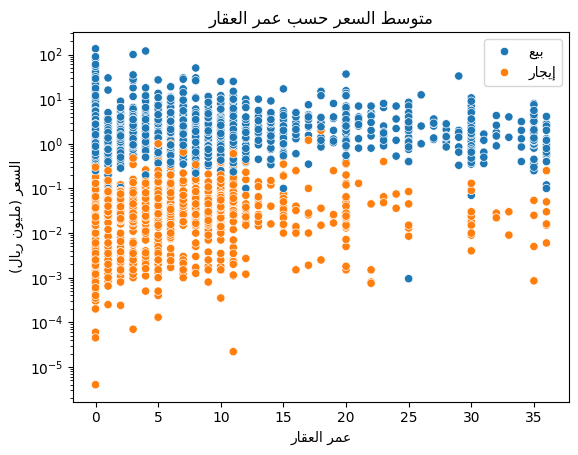

In [29]:
sns.scatterplot(data=df.sample(10000, random_state=42), x='age', y='price_million', hue='Contract type')
plt.yscale('log')
plt.ylabel(ar('السعر (مليون ريال)'))
plt.title(ar('متوسط السعر حسب عمر العقار'))
plt.xlabel(ar('عمر العقار'))

handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs])
plt.show()


- العمر لا يؤثر كثيراً على السعر
- معظم العقارات عمرها 0-10 سنوات
- العقارات الجديدة والقديمة بنفس نطاق الأسعار تقريباً
- البيع دائماً أعلى من الإيجار بغض النظر عن العمر


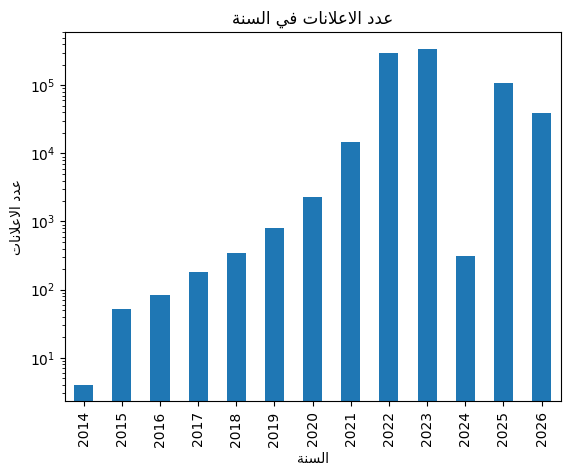

In [30]:
df['create_time'] = pd.to_datetime(df['create_time'], unit='s', errors='coerce')
df['year'] = df['create_time'].dt.year
df.groupby('year')['id'].count().plot(kind='bar')
plt.yscale('log')
plt.ylabel(ar('عدد الاعلانات'))
plt.title(ar('عدد الاعلانات في السنة'))
plt.xlabel(ar('السنة'))

plt.show()

- نمو تدريجي من 2014 حتى 2023
- ذروة النشاط في 2022-2023
- انخفاض حاد في 2024 بسبب توقف المشروع
- عودة النشاط في 2025-2026

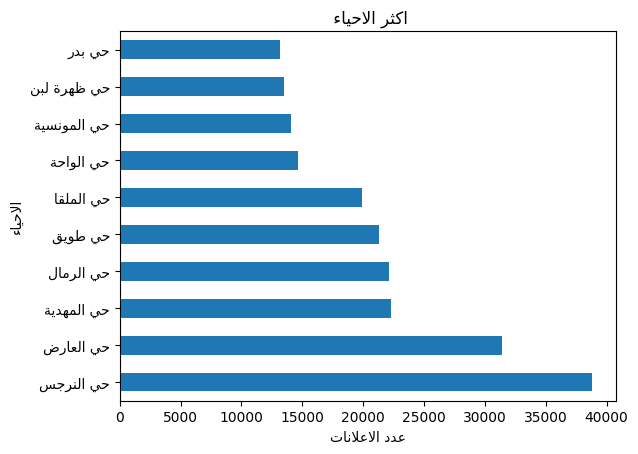

In [20]:
top_districts = df['district'].value_counts().head(10)
labels = [get_display(arabic_reshaper.reshape(d)) for d in top_districts.index]

top_districts.plot(kind='barh')
plt.yticks(range(len(labels)), labels)

plt.ylabel(ar('الاحياء'))
plt.xlabel(ar('عدد الاعلانات'))
plt.title(ar('اكثر الاحياء '))

plt.show()

- كل الأحياء العشرة من الرياض — يعكس هيمنتها على السوق
- حي النرجس الأول بفارق كبير عن الباقي
- حي العارض ثانياً — من أكبر أحياء شمال الرياض

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 25.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 27.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


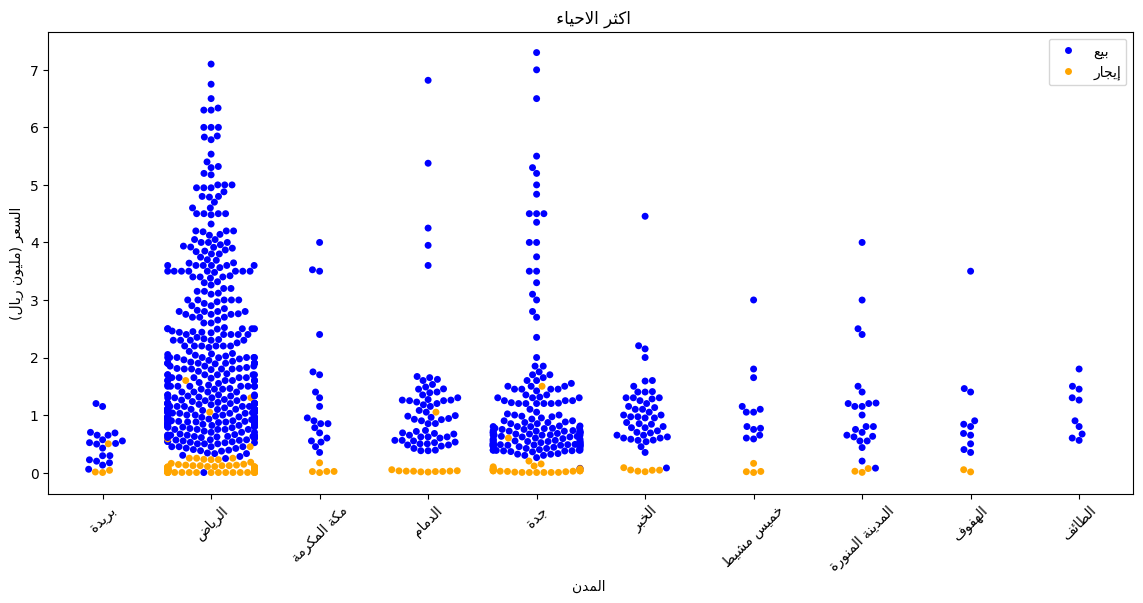

In [21]:
sample = df[df['city'].isin(top_cities) & (df['price'] < df['price'].quantile(0.95))].sample(1000, random_state=42)
sample['city_label'] = sample['city'].apply(lambda x: get_display(arabic_reshaper.reshape(x)))
sample['price_million'] = sample['price'] / 1_000_000

plt.figure(figsize=(14, 6))
sns.swarmplot(data=sample, x='city_label', y='price_million', hue='Contract type',
              palette={'بيع': 'blue', 'إيجار': 'orange'})

plt.ylabel(ar('السعر (مليون ريال)'))
plt.xlabel(ar(' المدن'))
plt.title(ar('اكثر الاحياء '))
handles, labs = plt.gca().get_legend_handles_labels()
plt.legend(handles, [ar(l) for l in labs])
plt.xticks(rotation=45)
plt.show()

- الرياض وجدة فيها أعلى تنوع في أسعار البيع
- الإيجار منخفض جداً ومتقارب في كل المدن
- بريدة أسعارها أقل من المدن الكبرى

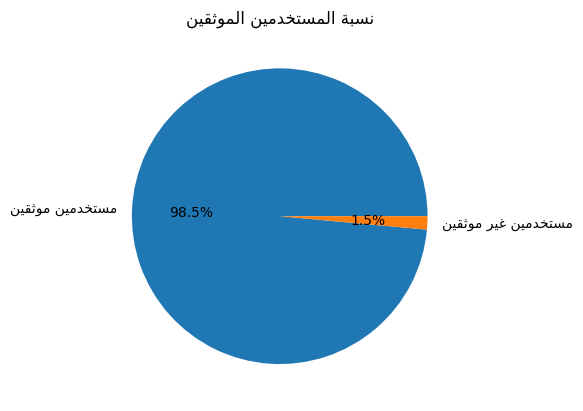

In [22]:
labels = {
    True: "مستخدمين موثّقين",
    False: "مستخدمين غير موثّقين"
}

reshaped_labels = {
    k: get_display(arabic_reshaper.reshape(v))
    for k, v in labels.items()
}

counts = df['user.iam_verified'].map(reshaped_labels).value_counts()


counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel=''
)

title = get_display(arabic_reshaper.reshape("نسبة المستخدمين الموثّقين"))
plt.title(title)

plt.show()



- 98.5% من المعلنين موثقين
- البيانات موثوقة جداً
- هذا العمود لن يكون مفيداً في تعلم الآلة بسبب شبه انعدام التباين

# Machine learning

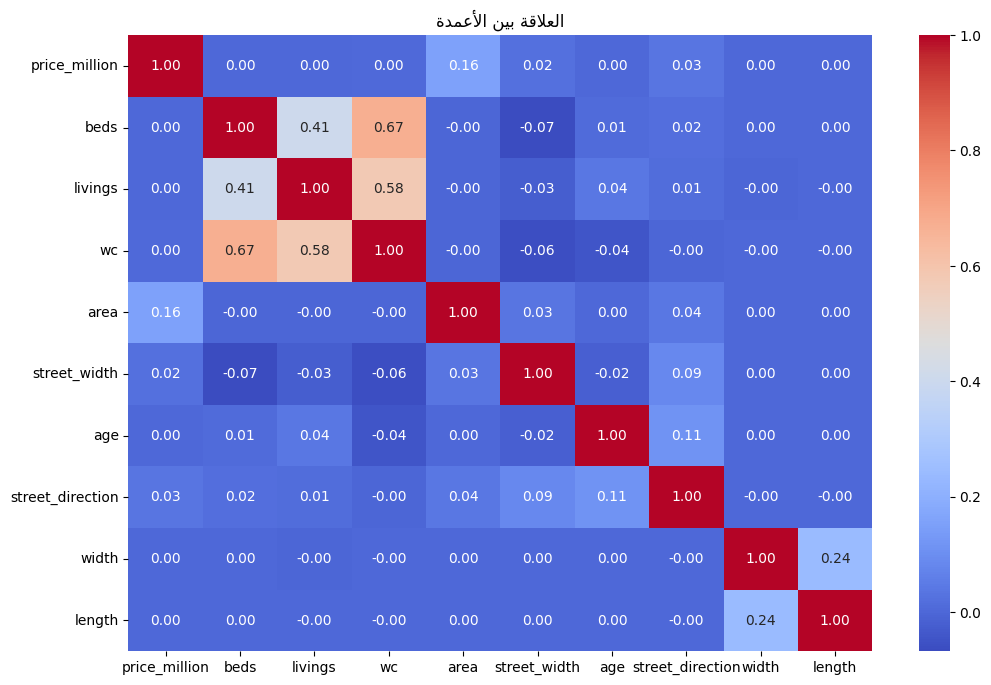

In [31]:

numeric_cols = ['price_million', 'beds', 'livings', 'wc', 'area',
                'street_width', 'age', 'street_direction', 'width', 'length']


plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title(ar('العلاقة بين الأعمدة'))
plt.show()

In [32]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder


features = ['beds', 'livings', 'wc', 'area', 'street_width', 'age',
            'city', 'district', 'property_type', 'Contract type', 'region']

df_model = df[features + ['price_million']].dropna()

le = LabelEncoder()
for col in ['city', 'district', 'property_type', 'Contract type', 'region']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[features]
y = df_model['price_million']

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=features).sort_values(ascending=False)
print(mi_series)

district         0.813925
area             0.735512
Contract type    0.554568
property_type    0.444804
wc               0.361481
livings          0.254705
city             0.244217
beds             0.212766
region           0.176177
age              0.160027
street_width     0.157501
dtype: float64
